Successfully found 1 .dat files!

Getting graph of original data vs what will be passed onto model

--- Sequence 0 Statistics ---
Analyzing File:                         curve_2018_0544.dat
Full Original Event Length:             373 points
Cut Training Sequence (before padding): 348 points
Valid Points (Kept for Training):       346 points
Points removed due to gaps (>30d):      2 points


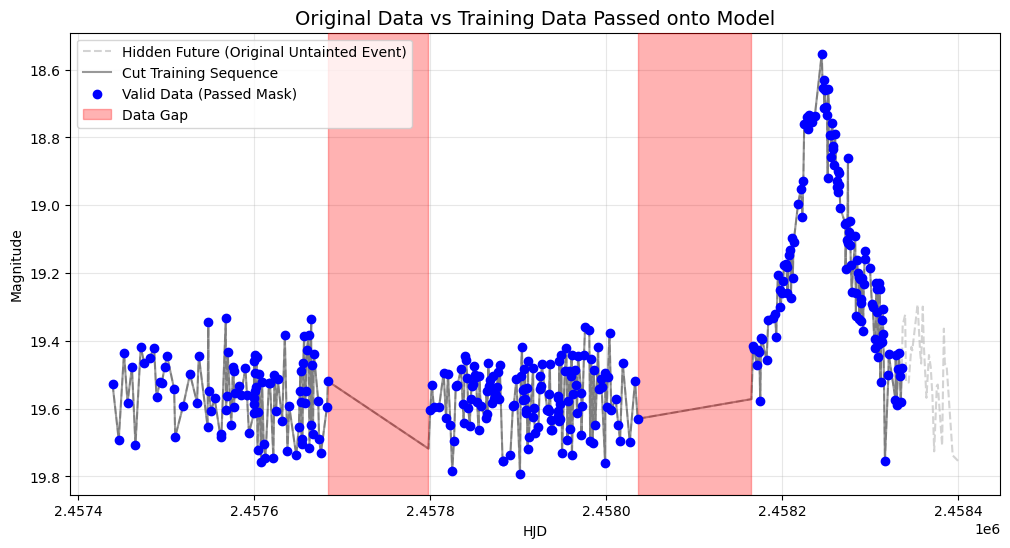

Graphing complete!


Does everything look correct? Should I move onto training and testing the model (yes/no):  yes


Training and testing starting...


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import numpy as np
import os
import random
import glob
import matplotlib.pyplot as plt
import sys

def compute_gap_mask(t): # makes mask for natural gaps in data
    threshold = 50 # most gaps are around 100*(2.5*10e6) so half of that

    dt = np.diff(t)
    g_mask = dt <= threshold
    g_mask = np.concatenate([[True], g_mask])
    return g_mask

class MicrolensingDataset(Dataset):
    def __init__(self, file_paths):
        self.file_paths = file_paths

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        # load the raw data
        data = np.loadtxt(self.file_paths[idx])

        # pick a random cut-off index + ensure there is at least some minimum history and some future to predict
        total_length = len(data)

        # find the peak of the event (np.argmin finds the index of the lowest value in an array)
        peak_idx = np.argmin(data[:, 1])

        # set the minimum history to be after the peak
        min_history_after_peak = peak_idx + 5

        # if the file is weird and the peak is at the very end, we can't cut after it.
        if min_history_after_peak >= total_length - 2:
            cutoff_idx = total_length - 1  # Just predict the very last point

        else:
            #pick a random cut-off that is AFTER the peak but before the very end of the file.
            cutoff_idx = random.randint(min_history_after_peak, total_length - 2)

        # split into input (X) and target (y)
        # X: everything up to the cutoff (Shape: [cutoff_idx, 2])
        # y: everything after the cutoff (Shape: [remaining_length, 1])
        X = data[:cutoff_idx, :]
        y = data[cutoff_idx:, 1:2]

        # extract the time column from input data
        time_steps = X[:, 0]

        dt = np.diff(time_steps)

        # call gap mask function
        numpy_gap_mask = compute_gap_mask(time_steps)

        # convert everything to PyTorch tensors
        X_tensor = torch.tensor(X, dtype=torch.float32)
        y_tensor = torch.tensor(y, dtype=torch.float32)
        X_length = X_tensor.shape[0]

        # convert your mask to a boolean tensor
        gap_mask_tensor = torch.tensor(numpy_gap_mask, dtype=torch.bool)

        return X_tensor, y_tensor, X_length, gap_mask_tensor

def pad_collate(batch):
    # separate the batch into individual lists
    x_list = [item[0] for item in batch]
    y_list = [item[1] for item in batch]
    x_lengths = [item[2] for item in batch]

    # pad with zeros
    x_padded = pad_sequence(x_list, batch_first=True, padding_value=0.0)
    y_padded = pad_sequence(y_list, batch_first=True, padding_value=0.0)

    # convert lengths to a tensor
    x_lengths_tensor = torch.tensor(x_lengths, dtype=torch.int64)

    # Grabs the 4th item from every file in the batch
    gap_masks_list = [item[3] for item in batch]

    # Pads them together
    gap_masks_padded = pad_sequence(gap_masks_list, batch_first=True, padding_value=False)

    return x_padded, y_padded, x_lengths_tensor, gap_masks_padded

#-------

file_path = "/Users/ongjo/coding/LIGHT/testing 2/2024/curve_2024_0009.dat"
lightcurves = glob.glob(file_path)

print(f"Successfully found {len(lightcurves)} .dat files!")

# make sure it actually found files
if len(lightcurves) > 0:
    dataset = MicrolensingDataset(lightcurves)
    dataloader = DataLoader(dataset, batch_size=8, collate_fn=pad_collate, shuffle=True)

#------------

print("\nGetting graph of original data vs what will be passed onto model")

# create a temporary dataloader WITHOUT shuffling so we can match the file
test_loader = DataLoader(dataset, batch_size=8, collate_fn=pad_collate, shuffle=False)

for X_padded, y_padded, lengths, gap_masks in test_loader:

    # recreate the exact masking logic
    max_len = X_padded.size(1)
    pad_mask = torch.arange(max_len)[None, :] < lengths[:, None]
    final_mask = pad_mask & gap_masks

    # isolate the FIRST sequence (index 0)
    idx = 0
    x_seq = X_padded[idx].numpy()
    p_mask = pad_mask[idx].numpy()
    f_mask = final_mask[idx].numpy()

    hjd = x_seq[:, 0]
    mag = x_seq[:, 1]
    true_len = lengths[idx].item()

    # LOAD THE UNTAINTED ORIGINAL DATA
    # Because shuffle=False, index 0 matches the first file in your dataset list
    original_file = dataset.file_paths[idx]

    # Extracts just the file name from the long folder path
    clean_file_name = os.path.basename(original_file)

    raw_data = np.loadtxt(original_file)
    raw_hjd = raw_data[:, 0]
    raw_mag = raw_data[:, 1]

    # Print stats
    print(f"\n--- Sequence {idx} Statistics ---")

    print(f"Analyzing File:                         {clean_file_name}")

    print(f"Full Original Event Length:             {len(raw_hjd)} points")
    print(f"Cut Training Sequence (before padding): {true_len} points")
    print(f"Valid Points (Kept for Training):       {f_mask.sum()} points")
    print(f"Points removed due to gaps (>30d):      {true_len - f_mask.sum()} points")

    plt.figure(figsize=(12, 6))

    # Plot the FULL original untainted event (Faint Dashed Gray)
    plt.plot(raw_hjd, raw_mag, color='lightgray', linestyle='--', zorder=1,
             label='Hidden Future (Original Untainted Event)')

    # Plot the solid line for the CUT sequence the model actually sees (Solid Black)
    plt.plot(hjd[:true_len], mag[:true_len], color='black', alpha=0.4, zorder=2,
            label='Cut Training Sequence')

    # Plot the VALID data points (Blue)
    plt.scatter(hjd[f_mask], mag[f_mask], color='blue', zorder=4,label='Valid Data (Passed Mask)')

    # Draw RED BARS for every gap
    is_gap = p_mask & (~f_mask)
    gap_indices = np.where(is_gap)[0]

    # We use a flag so we only add 'Data Gap' to the legend once,
    # instead of creating a new legend entry for every single bar.
    added_gap_label = False

    for idx in gap_indices:
        # Draw a vertical red span from the last valid point (idx-1)
        # to the point immediately following the gap (idx)
        plt.axvspan(
            hjd[idx - 1],
            hjd[idx],
            color='red',
            alpha=0.3,
            zorder=3,
            label='Data Gap' if not added_gap_label else ""
        )
        added_gap_label = True

    # Formatting
    plt.gca().invert_yaxis()  # Invert Y axis for magnitudes
    plt.title("Original Data vs Training Data Passed onto Model", fontsize=14)
    plt.xlabel("HJD")
    plt.ylabel("Magnitude")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    break  # Stop after the first batch

#---- Asks if you'd like to continue onto training and testing the model

print("Graphing complete!")

# Ask user to continue
response = input("Does everything look correct? Should I move onto training and testing the model (yes/no): ").lower()

if response not in ("yes", "y"):
    print("Stopping execution.")
    sys.exit()

print("Training and testing starting...")

#-------

In [2]:
# =========================
# 1. Simple microlensing physics functions
# =========================
import torch.nn as nn
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


def magnification_torch(u):
    """
    Point-source point-lens magnification.
    u: tensor
    """
    eps = 1e-6
    u = torch.clamp(u, min=eps)
    return (u**2 + 2.0) / (u * torch.sqrt(u**2 + 4.0))


def microlensing_mag_torch(t, t0, tE, u0, I0, fbl):
    """
    Single-source single-lens microlensing model in magnitude space.

    Parameters
    ----------
    t   : observation times
    t0  : time of maximum magnification
    tE  : Einstein timescale
    u0  : minimum impact parameter
    I0  : baseline magnitude
    fbl : blending fraction in [0, 1)

    Returns
    -------
    model magnitude at time t
    """
    u = torch.sqrt(u0**2 + ((t - t0) / tE)**2)
    A = magnification_torch(u)

    # blended flux ratio: baseline flux normalized to 1
    # fbl = source-flux fraction
    flux_ratio = fbl * A + (1.0 - fbl)


    mag = I0 - 2.5 * torch.log10(flux_ratio)
    return mag


def read_params_file(params_file):
    """
    Read OGLE-style params.dat file into a dictionary.
    """
    params = {}

    with open(params_file, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 2:
                key = parts[0]

                if key in ["Tmax", "tau", "umin", "Amax", "Dmag", "fbl", "I_bl", "I0"]:
                    try:
                        value = float(parts[1])
                        params[key] = value
                    except ValueError:
                        pass

    return params
    

Using device: cpu


In [3]:
# =========================
# 2. Prepare one event for fitting and prediction
# =========================
def prepare_single_event(cutoff_file, full_file):
    """
    cutoff_file: already-cut observed data
    full_file: full light curve containing the true future points
    """
    cutoff_data = np.loadtxt(cutoff_file, skiprows=1)
    full_data = np.loadtxt(full_file)

    # Assume column 0 = time, column 1 = magnitude
    t_obs = cutoff_data[:, 0]
    m_obs = cutoff_data[:, 1]

    t_all = full_data[:, 0]
    m_all = full_data[:, 1]

    cutoff_idx = len(t_obs)

    # Safety check: cutoff file should match the first part of full file
    if cutoff_idx > len(t_all):
        raise ValueError("cutoff file is longer than full file.")

    if not np.allclose(t_obs, t_all[:cutoff_idx]):
        raise ValueError("cutoff file does not match the beginning of full file in time column.")

    # Future = everything after the observed cutoff
    t_future = t_all[cutoff_idx:]
    m_future = m_all[cutoff_idx:]

    # For fitting, directly use all observed cutoff data
    t_fit = t_obs
    m_fit = m_obs

    gap_mask = compute_gap_mask(t_obs)

    return {
        "t_all": t_all,
        "m_all": m_all,
        "t_obs": t_obs,
        "m_obs": m_obs,
        "t_future": t_future,
        "m_future": m_future,
        "t_fit": t_fit,
        "m_fit": m_fit,
        "cutoff_idx": cutoff_idx,
        "gap_mask": gap_mask
    }

In [4]:
# =========================
# 3. Simple parameter-fitting model
# =========================
class SimpleMicrolensingFitter(nn.Module):
    def __init__(self, t_init, m_init):
        super().__init__()

        # Better initialization:
        # t0 starts near the brightest observed point
        t0_guess = float(t_init[np.argmin(m_init)])

        # --- better baseline estimate: only use the early pre-event points ---
        n_init = max(20, len(m_init) // 5)   # first 20% points, at least 20
        m_early = m_init[:n_init]
        I0_guess = float(np.median(m_early))

        # --- better tE guess: use where the curve starts departing from baseline ---
        t_range = float(np.max(t_init) - np.min(t_init))
        deviation = np.abs(m_init - I0_guess)

        # threshold for "significant brightening"
        thresh = max(0.03, 2.0 * np.std(m_early))

        active_idx = np.where(deviation > thresh)[0]
        if len(active_idx) >= 2:
            event_width = float(t_init[active_idx[-1]] - t_init[active_idx[0]])
            tE_guess = max(event_width, 30.0)
        else:
            tE_guess = max(t_range / 5.0, 30.0)

        u0_guess = 0.2
        fbl_guess = 0.8

        
        self.t0_raw = nn.Parameter(torch.tensor(t0_guess, dtype=torch.float32))
        self.log_tE = nn.Parameter(torch.tensor(np.log(tE_guess), dtype=torch.float32))
        self.log_u0 = nn.Parameter(torch.tensor(np.log(u0_guess), dtype=torch.float32))
        self.I0_raw = nn.Parameter(torch.tensor(I0_guess, dtype=torch.float32))

        # inverse-sigmoid style rough init
        fbl_raw_guess = np.log(fbl_guess / (1.0 - fbl_guess))
        self.fbl_raw = nn.Parameter(torch.tensor(fbl_raw_guess, dtype=torch.float32))

    def get_physical_params(self):
        t0 = self.t0_raw
        tE = torch.exp(self.log_tE) + 1e-4
        u0 = torch.exp(self.log_u0) + 1e-4
        I0 = self.I0_raw
     #   fbl = torch.sigmoid(self.fbl_raw) * 0.95   # keep in (0, 0.95)
        fbl = 0.05 + 0.94 * torch.sigmoid(self.fbl_raw)   # keep in (0.05, 0.99)

        return t0, tE, u0, I0, fbl

    def forward(self, t):
        t0, tE, u0, I0, fbl = self.get_physical_params()
        return microlensing_mag_torch(t, t0, tE, u0, I0, fbl)

In [5]:
# =========================
# 4. Fit one event with PyTorch
# =========================
def fit_single_event(event_dict, num_epochs=4000, lr=0.01, verbose=True):
    t_fit_np = event_dict["t_fit"]
    m_fit_np = event_dict["m_fit"]

    t_fit = torch.tensor(t_fit_np, dtype=torch.float32, device=device)
    m_fit = torch.tensor(m_fit_np, dtype=torch.float32, device=device)

    model = SimpleMicrolensingFitter(t_fit_np, m_fit_np).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    # --- better weights: baseline + peak + cutoff-end all matter ---
    n_early = max(20, len(m_fit_np) // 5)
    baseline_est = np.median(m_fit_np[:n_early])

    amp_est = np.maximum(baseline_est - m_fit_np, 0.0)
    amp_norm = amp_est / (np.max(amp_est) + 1e-6)

    N = len(m_fit_np)
    x = np.linspace(0.0, 1.0, N)

    # emphasize the last 15% points before cutoff
    end_boost = np.zeros(N)
    end_mask = x > 0.85
    end_boost[end_mask] = (x[end_mask] - 0.85) / 0.15

    # emphasize the first 20% baseline points too
    front_boost = np.zeros(N)
    front_mask = x < 0.20
    front_boost[front_mask] = 1.0 - x[front_mask] / 0.20

    weights_np = (
        1.0
        + 3.0 * front_boost      # fit the starting baseline better
        + 5.0 * amp_norm         # fit the peak / bright region
        + 6.0 * end_boost        # fit the cutoff-near region better
    )

    weights = torch.tensor(weights_np, dtype=torch.float32, device=device)

    loss_history = []

    for epoch in range(num_epochs):
        optimizer.zero_grad()

        pred = model(t_fit)

        # Weighted MSE
        mse_loss = torch.mean(weights * (pred - m_fit) ** 2)

        # Small regularization to discourage absurdly huge u0 and tE
        t0, tE, u0, I0, fbl = model.get_physical_params()
        #reg_loss = 1e-4 * (tE ** 2) + 1e-3 * (u0 ** 2)
        reg_loss = 1e-5 * (u0 ** 2)

        loss = mse_loss + reg_loss

        loss.backward()
        optimizer.step()

        loss_history.append(loss.item())

        if verbose and (epoch == 0 or (epoch + 1) % 500 == 0):
            print(
                f"Epoch {epoch+1:4d} | "
                f"Loss = {loss.item():.6f} | "
                f"t0 = {t0.item():.3f}, "
                f"tE = {tE.item():.3f}, "
                f"u0 = {u0.item():.3f}, "
                f"I0 = {I0.item():.3f}, "
                f"fbl = {fbl.item():.3f}"
            )

    t0, tE, u0, I0, fbl = model.get_physical_params()
    fitted_params = {
        "Tmax_fit": t0.item(),
        "tau_fit": tE.item(),
        "umin_fit": u0.item(),
        "I0_fit": I0.item(),
        "fbl_fit": fbl.item()
    }

    return model, fitted_params, loss_history

In [6]:
@torch.no_grad()
def evaluate_and_plot_event(model, event_dict, n_future_plot=10):
    t_obs = event_dict["t_obs"]
    m_obs = event_dict["m_obs"]
    t_future = event_dict["t_future"]
    m_future = event_dict["m_future"]
    t_all = event_dict["t_all"]
    m_all = event_dict["m_all"]
    gap_mask = event_dict["gap_mask"]

    t_obs_tensor = torch.tensor(t_obs, dtype=torch.float32, device=device)
    t_future_tensor = torch.tensor(t_future, dtype=torch.float32, device=device)
    t_all_tensor = torch.tensor(t_all, dtype=torch.float32, device=device)

    pred_all = model(t_all_tensor).cpu().numpy()
    pred_future = model(t_future_tensor).cpu().numpy()

    if n_future_plot is not None:
        t_future_plot = t_future[:n_future_plot]
        m_future_plot = m_future[:n_future_plot]
        pred_future_plot = pred_future[:n_future_plot]
    else:
        t_future_plot = t_future
        m_future_plot = m_future
        pred_future_plot = pred_future

    future_mse = np.mean((pred_future_plot - m_future_plot) ** 2)
    future_mae = np.mean(np.abs(pred_future_plot - m_future_plot))

    print("\nFuture prediction metrics:")
    print(f"Future MSE: {future_mse:.6f}")
    print(f"Future MAE: {future_mae:.6f}")

    plt.figure(figsize=(12, 6))

    # full raw event
    plt.plot(t_all, m_all, color="lightgray", linestyle="--", label="Full Original Event", zorder=1)

    # all observed points
    plt.scatter(t_obs, m_obs, color="blue", s=20, label="Observed Points", zorder=3)

    # fitted model
    plt.plot(t_all, pred_all, color="green", linewidth=2, label="Fitted Microlensing Model", zorder=2)

    # future truth
    plt.scatter(t_future_plot, m_future_plot, color="black", s=30, label="True Future Points", zorder=4)

    # future prediction
    plt.scatter(t_future_plot, pred_future_plot, color="red", s=30, label="Predicted Future Points", zorder=5)

    plt.gca().invert_yaxis()
    plt.xlabel("HJD")
    plt.ylabel("Magnitude")
    plt.title("Microlensing Fit and Future-Point Prediction")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    return {"future_mse": future_mse, "future_mae": future_mae}

In [7]:
# =========================
# 6. Compare fitted parameters with params.dat
# =========================
def compare_with_true_params(fitted_params, params_file):
    true_params = read_params_file(params_file)

    print("\nComparison with params.dat:")
    print("-" * 50)

    compare_pairs = [
        ("Tmax", "Tmax_fit"),
        ("tau", "tau_fit"),
        ("umin", "umin_fit"),
        ("I0", "I0_fit"),
        ("fbl", "fbl_fit")
    ]

    for true_key, fit_key in compare_pairs:
        true_val = true_params.get(true_key, None)
        fit_val = fitted_params.get(fit_key, None)

        if true_val is not None and fit_val is not None:
            abs_err = abs(fit_val - true_val)
            print(f"{true_key:6s} | true = {true_val:12.6f} | fit = {fit_val:12.6f} | abs err = {abs_err:12.6f}")
        else:
            print(f"{true_key:6s} | missing in one of the dictionaries")

    return true_params
    

Cutoff file: /Users/skyxu/Downloads/curve_2018_0199_cutoff.dat
Full file: /Users/skyxu/Downloads/curve_2018_0199.dat
Params file: /Users/skyxu/Downloads//params_2018_0199.dat

Event summary:
Total points:    799
Observed points: 563
Fit points:      563
Future points:   236
Epoch    1 | Loss = 1.386776 | t0 = 2458230.750, tE = 715.863, u0 = 0.200, I0 = 16.958, fbl = 0.802
Epoch  500 | Loss = 0.048416 | t0 = 2458230.750, tE = 275.346, u0 = 0.402, I0 = 17.047, fbl = 0.619
Epoch 1000 | Loss = 0.000996 | t0 = 2458230.750, tE = 69.645, u0 = 0.333, I0 = 16.940, fbl = 0.557
Epoch 1500 | Loss = 0.000963 | t0 = 2458230.750, tE = 67.999, u0 = 0.331, I0 = 16.938, fbl = 0.558
Epoch 2000 | Loss = 0.000962 | t0 = 2458230.750, tE = 67.897, u0 = 0.332, I0 = 16.938, fbl = 0.559
Epoch 2500 | Loss = 0.000962 | t0 = 2458230.750, tE = 67.762, u0 = 0.333, I0 = 16.938, fbl = 0.561
Epoch 3000 | Loss = 0.000961 | t0 = 2458230.750, tE = 67.589, u0 = 0.334, I0 = 16.938, fbl = 0.564
Epoch 3500 | Loss = 0.000960 |

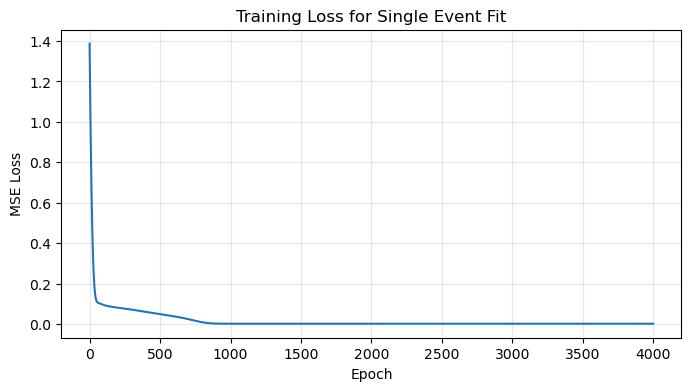


Future prediction metrics:
Future MSE: 0.001693
Future MAE: 0.034125


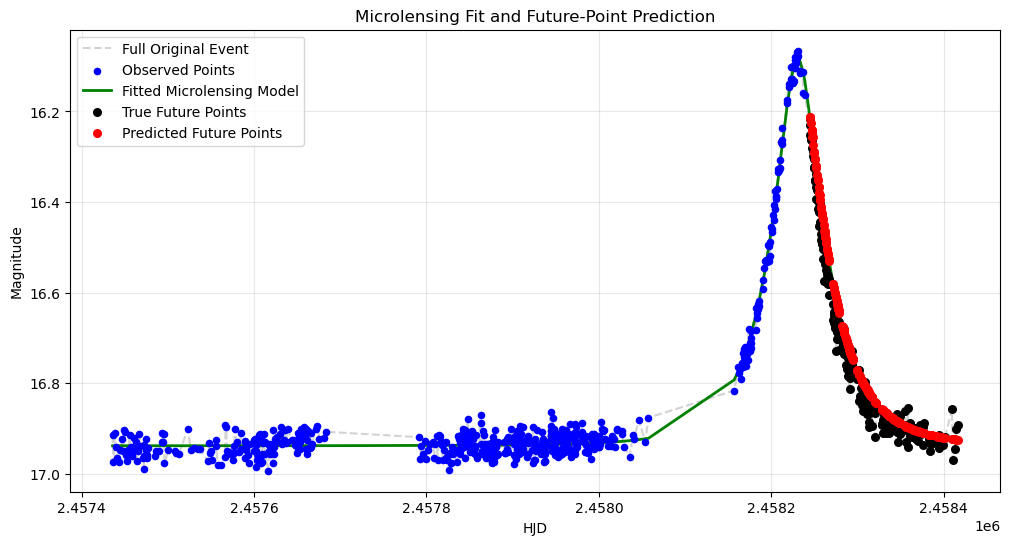


Comparison with params.dat:
--------------------------------------------------
Tmax   | true = 2458228.980000 | fit = 2458230.750000 | abs err =     1.770000
tau    | true =    54.471000 | fit =    67.096794 | abs err =    12.625794
umin   | true =     0.412000 | fit =     0.337505 | abs err =     0.074495
I0     | true =    17.245000 | fit =    16.937977 | abs err =     0.307023
fbl    | true =     0.754000 | fit =     0.571641 | abs err =     0.182359

Fitted parameters dictionary:
{'Tmax_fit': 2458230.75, 'tau_fit': 67.09679412841797, 'umin_fit': 0.33750489354133606, 'I0_fit': 16.937976837158203, 'fbl_fit': 0.571641206741333}

True parameters dictionary:
{'Tmax': 2458228.98, 'tau': 54.471, 'umin': 0.412, 'Amax': 2.577, 'Dmag': 1.028, 'fbl': 0.754, 'I_bl': 16.938, 'I0': 17.245}


In [ ]:
# =========================
# 7. Run one complete example
# =========================

# Observed cutoff data (already cut, do NOT cut again)
cutoff_file = "/Users/skyxu/Downloads/curve_2018_0199_cutoff.dat"
print("Cutoff file:", cutoff_file)

# Full light curve (contains true future points after cutoff)
full_file = "/Users/skyxu/Downloads/curve_2018_0199.dat"
print("Full file:", full_file)

# Params file for later comparison
params_file = "/Users/skyxu/Downloads/params_2018_0199.dat"  
print("Params file:", params_file)

# Prepare one event
event_dict = prepare_single_event(cutoff_file, full_file)
print("\nEvent summary:")
print("Total points:   ", len(event_dict["t_all"]))
print("Observed points:", len(event_dict["t_obs"]))
print("Fit points:     ", len(event_dict["t_fit"]))
print("Future points:  ", len(event_dict["t_future"]))

# Fit model
model, fitted_params, loss_history = fit_single_event(
    event_dict,
    num_epochs=4000,
    lr=0.01,
    verbose=True
)

# Plot training loss
plt.figure(figsize=(8, 4))
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training Loss for Single Event Fit")
plt.grid(True, alpha=0.3)
plt.show()

# Evaluate future prediction
metrics = evaluate_and_plot_event(model, event_dict, n_future_plot=None)

# Compare fitted params with true params file
true_params = compare_with_true_params(fitted_params, params_file)

print("\nFitted parameters dictionary:")
print(fitted_params)

print("\nTrue parameters dictionary:")
print(true_params)
